## Exercise 2: Goal-conditioned Reinforcement Learning
<img src="gcrl/rlvsgcrl.png" width="1000" height="auto"/>

### Hindsight Experience Replay (HER)

- sparse reward setting (e.g. binary rewards: goal reached vs. not reached) $\Rightarrow$ mostly negative experience
- HER [4]: relabel goals with achieved states, recompute rewards for all transitions

<img src="gcrl/her.png" width="800" height="auto"/>


### Goal-conditioned Supervised Learning (GCSL)
- treat failed trajectories as success by relabeling the goal [3]:

    <img src="gcrl/gcsl.png" width="1000" height="auto"/>
- use relabeled trajectories for supervised learning:

    - $\pi_{\theta}^\ast \leftarrow \arg\max_{\pi_{\theta}} \mathbb{E}_{(s,a,g,h) \sim \mathcal{D}} \left[ \log \pi_{\theta}(a \mid s, g, h) \right]$
    where $h$ is the horizon, i.e. number of steps left

- in practice: horizon not required

### Contrastive Reinforcement Learning (CRL)
- learn a critic which knows to tell apart future outcomes from random outcomes [1]:

    <img src="gcrl/crl.png" width="1000" height="auto"/>
- contrastive learning:

    - $Q_{\Theta}^\ast \leftarrow \arg\max_{Q_{\Theta}} \mathbb{E}_{(s,a,g^+, g^-) \sim \mathcal{D}}
    \left[
        \log \sigma(\phi_\Theta(s,a)^T \psi_\Theta(g^+)) + \log(1 - \sigma(\phi_\Theta(s,a)^T \psi_\Theta(g^-)))
    \right]$ 

    - where $Q_{\Theta}(s,a,g) = \phi_\Theta(s,a)^T \psi_\Theta(g)$

- update policy by differentiating through critic:

    - $\pi_{\theta}^\ast \leftarrow \arg\max_{\pi_{\theta}} \mathbb{E}_{(s,g) \sim \mathcal{D}, a \sim \pi_{\Theta}(a | s, g)} Q(s,a,g)$
    - Note: requires differentiable sampling in policy!



### References
- [1] Benjamin Eysenbach, Tianjun Zhang, Ruslan Salakhutdinov, & Sergey Levine. (2023). Contrastive Learning as Goal-Conditioned Reinforcement Learning. (https://arxiv.org/abs/2206.07568)
- [2] Chongyi Zheng, Benjamin Eysenbach, Homer Walke, Patrick Yin, Kuan Fang, Ruslan Salakhutdinov, & Sergey Levine. (2025). Stabilizing Contrastive RL: Techniques for Robotic Goal Reaching from Offline Data. (https://arxiv.org/abs/2306.03346)
- [3] Dibya Ghosh, Abhishek Gupta, Ashwin Reddy, Justin Fu, Coline Devin, Benjamin Eysenbach, & Sergey Levine. (2020). Learning to Reach Goals via Iterated Supervised Learning. (https://arxiv.org/abs/1912.06088)
- [4] Marcin Andrychowicz, Filip Wolski, Alex Ray, Jonas Schneider, Rachel Fong, Peter Welinder, Bob McGrew, Josh Tobin, Pieter Abbeel, & Wojciech Zaremba. (2018). Hindsight Experience Replay.  (https://arxiv.org/abs/1707.01495)


## Example: Goal-conditioned RL in the Switchboard Environment
- **Policy representation**
    - $N$ actions which are independent and binary ($0$ or $1$)
    - modelled as Bernoulli distribution (learnable probabilities)
    - differentiable with straight-through estimator: 

        - $sample^\prime = sample + \underbrace{probs - probs.detach()}_{=0}$

- **Observations**: $M$ slots with values between $0$ and $1$
- **Goals**: 
    - goals are target observations
    - assumption: 
        - we want to trigger each individual slot during training $\Rightarrow$ goals are single active slots (one-hot)
        - we can compute similarity in observation space to check for goal attainment:
            - $r_t = \begin{cases} 1 & \text{if } ||o_t - g||_2^2 \le 0.01 \\ 0 & \text{else} \end{cases}$
        - **Note**: these assumptions are quite restrictive in general
            - for e.g. high dimensional image observations we can not easily generate goals
            - Euclidean distance in image space may not be reasonable
- **Environment**:
    - turn-taking mode
    - sequential rules & slot-dependent rules
    - episode length: $10$ steps 


In [40]:
import os
os.chdir("../")
import torch
from environments.switchboard.switchboard import Switchboard

from rl.policies import BernoulliPolicy
from rl.buffer import EpisodicBuffer

import random

from rl.crl import ContrastiveQf, StableContrastiveRL
from rl.a2c import AdvantageActorCritic, Critic
from rl.gcsl import GCSL

# Viszualization & Logging
from rl.viz import plot_metrics, evaluate_agent_goal_attainment
from rl.util import ExperimentLogger
from IPython.display import clear_output

device = "cpu"
torch.set_default_device(device)

## Environment Setup

In [41]:
## Environment

action_dim = 10
obs_dim = 10
num_episodes = 50000
episode_length = 10

env = Switchboard(action_dim=action_dim, obs_dim=obs_dim, time_scaling=0.0, device=device) # time_scaling = 0.0: turn taking
env.load_rules('hard_rules') 

# Print rules
print("Rules:")
print("\n".join([rule["description"] for rule in env.list_rules()]))


# Goal sampling:
class SingleSlotGoalSampler:
    """
        Samples a goal where only one slot is active at a time.
    """
    def sample(self, batch_size):
        goals = torch.zeros((batch_size, obs_dim), device=device)
        indices = torch.randint(0, obs_dim, (batch_size,), device=device)
        goals[torch.arange(batch_size), indices] = 1.0
        return goals
    
goal_sampler = SingleSlotGoalSampler()

def reward_function(next_obs, goal):
    """
        Simple distance based binary reward. If next_obs is close enough to goal, return 1, else 0.
    """
    return (torch.nn.functional.mse_loss(next_obs, goal) < 0.01).float()


✓ Loaded 10 rules from HardRules
Rules:
Sequence [0, 1, 2] -> Slot 0
Sequence [3, 4, 5, 6] -> Slot 1
Sequence [5, 6, 7, 8, 9] -> Slot 2
Exactly buttons [0,3,7], no others -> Slot 3
Buttons [1, 4, 9] -> Slot 4 (AND)
Slot 0 active + Button 8 → Slot 5
Slots 1&2 active + Button 9 → Slot 6
Button 2 (only if 5 never pressed in episode) → Slot 7
Alternating: Button 0 ON, OFF, ON, OFF → Slot 8
Slots 0,1,2 active + Button 0 + Even buttons → Slot 9


In [42]:
class ProbabilisticGoalSampler:
    """
        Samples a goal where each slot is active with probability p.
    """
    def __init__(self, obs_dim, p=0.3, device='cpu'):
        self.obs_dim = obs_dim
        self.p = p  # Probability of a slot being active
        self.device = device
        self.counter = 0

    def sample(self, batch_size):
        rand_tensor = torch.rand((batch_size, self.obs_dim), device=self.device)
        # Goals are 1.0 where the random number is less than p
        goals = (rand_tensor < self.p).float()
        
        # avoid the trivial goals
        while (goals.sum(dim=1) == 0).any():
            rand_tensor = torch.rand((batch_size, self.obs_dim), device=self.device)
            goals = (rand_tensor < self.p).float()
            
        return goals


probablityHardGoals = 0.5
probabilisticGoalSampler = ProbabilisticGoalSampler(obs_dim=obs_dim, p=probablityHardGoals, device=device)
probabilisticGoalSampler.sample(5)

tensor([[1., 1., 0., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 1., 0., 0., 1., 0., 1.],
        [1., 0., 1., 0., 0., 1., 1., 1., 0., 1.],
        [0., 1., 1., 0., 0., 0., 0., 1., 0., 1.],
        [1., 0., 0., 0., 1., 0., 1., 1., 0., 0.]])

In [43]:
class ImpossibleGoalSampler:
    """
        Generates goals outside the agent's achievable state space.
    """
    def __init__(self, obs_dim, p_impossible=0.1, device='cpu'):
        self.obs_dim = obs_dim
        self.p_impossible = p_impossible # Probability of sampling an impossible value
        self.device = device

    def sample(self, batch_size):
        goals = torch.randint(0, 2, (batch_size, self.obs_dim), device=self.device).float()
        impossible_mask = (torch.rand((batch_size, self.obs_dim), device=self.device) < self.p_impossible)

        goals[impossible_mask] = 1.1 
            
        return goals

p_impossible = 0.1
impossibleGoalSampler = ImpossibleGoalSampler(obs_dim=obs_dim, p_impossible=p_impossible)

In [44]:
class ProbabilisticImpossibleGoalSampler:
    """
        Samples a goal where each slot is active with probability p.
    """
    def __init__(self, obs_dim, p=0.3, device='cpu'):
        self.obs_dim = obs_dim
        self.p = p  # Probability of a slot being active
        self.device = device
        self.counter = 0

    def sample(self, batch_size):
        rand_tensor = torch.rand((batch_size, self.obs_dim), device=self.device)
        goals = (rand_tensor < self.p).float()
        if (self.counter % 50 == 0):
            impossible_mask = (torch.rand((batch_size, self.obs_dim), device=self.device) < 0.01)
            goals[impossible_mask] = 1.1 
        else :
            rand_tensor = torch.rand((batch_size, self.obs_dim), device=self.device)
            # Goals are 1.0 where the random number is less than p
            print(rand_tensor)
            goals = (rand_tensor < self.p).float()
            
        return goals


probablityHardGoals = 0.1
prop_impo_goal = ProbabilisticImpossibleGoalSampler(obs_dim=obs_dim, p=probablityHardGoals, device=device)

In [45]:
class SequentialGoalSampler:
    """
        Generates a sequence of K subgoals, each being a OneSlot or MultiSlotGoal.
    """
    def __init__(self, obs_dim, K_max=5, max_active_slots=3, device='cpu'):
        self.obs_dim = obs_dim
        self.K_max = K_max  # Max length of sequence
        self.max_active_slots = max_active_slots
        self.device = device

    def sample(self, batch_size):
        goal_sequences = [] 
        
        for _ in range(batch_size):
            # length of sequence
            K = random.randint(1, self.K_max)
            sequence = []

            for k in range(K):
                # random Number of goals
                num_active = random.randint(1, self.max_active_slots)
                g_k = torch.zeros(self.obs_dim, device=self.device)
                
                # Set Num_active slots
                indices = torch.randperm(self.obs_dim, device=self.device)[:num_active]
                g_k[indices] = 1.0
                
                # Filter duplicate subgoals
                duplicate_goal = any(torch.equal(g_k, x) for x in sequence)
                if(not duplicate_goal):
                    sequence.append(g_k)
                
            
            goal_sequences.append(sequence)
            
        return goal_sequences
    

sequentialGoalSampler = SequentialGoalSampler(obs_dim=obs_dim, K_max=5, max_active_slots=2, device=device)
seq_goal = sequentialGoalSampler.sample(1)
print(seq_goal)

[[tensor([0., 0., 0., 1., 0., 0., 0., 0., 1., 0.]), tensor([0., 1., 0., 1., 0., 0., 0., 0., 0., 0.]), tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])]]


## Replay Buffer
- add data with ```buffer.append(...)```
- sample data with ```buffer.sample(...)```
- new episode with ```buffer.new_episode()```
- if buffer is full, old entries are overwritten

In [46]:
buffer_shapes = ( 
    {
        "step": [1],
        "observation": [obs_dim],
        "action": [action_dim],
        "reward": [1],
        "desired_goal": [obs_dim],
    }
)
example_buffer = EpisodicBuffer(device=device, num_episodes=1000, max_episode_length=episode_length, shapes = buffer_shapes) 



for episode in range(100):
    obs = env.reset()
    goal = goal_sampler.sample(1)
    success = 0.0
    for step in range(episode_length):
        action = torch.zeros((1, action_dim), device=device)
        next_obs, _ = env.step(lambda o: action) # turn taking, do not care about computation time
        reward = reward_function(next_obs, goal) # this is hand-crafted and only used for A2C
        example_buffer.append({ 
            'observation': obs.reshape(1, -1),
            'action': action.reshape(1, -1),
            'desired_goal': goal.reshape(1, -1),
            'reward': reward.reshape(1, -1),
        })
        obs = next_obs
    example_buffer.new_episode()
    

# Usage:
        
data = example_buffer.sample(batch_size=16, trajectory_len=5)
print(f"Keys: {[key for key in data.keys()]}")
print(f"Observation sequence: {data['observation'].shape}")  # should be (16, 5, obs_dim)
empty_data = example_buffer.sample(batch_size=16, trajectory_len=100)
print(f"Too long: {empty_data}")

Keys: ['episodes', 'flattened_indices', 'step', 'observation', 'action', 'reward', 'desired_goal']
Observation sequence: torch.Size([16, 5, 10])
Too long: None


## Agent Setup
Here we compare AC, GCSL and CRL. Each agent gets its own experience buffer.

In [47]:

# A2C agent:
ac_policy = BernoulliPolicy(obs_shape=obs_dim, goal_shape=obs_dim, action_shape=action_dim)
ac_critic = Critic(obs_shape=obs_dim, goal_shape=obs_dim)
ac_agent = AdvantageActorCritic(device=device, policy=ac_policy, critic=ac_critic, trajectory_length=10, batch_size=256, adaptive_entropy_coefficient=False, kl_entropy=True, use_moments=False, use_advantage=False, differentiable_policy=False, kl_target=1.0, kl_alpha=1.0)
ac_buffer = EpisodicBuffer(device=device, num_episodes=5000, max_episode_length=episode_length, shapes = buffer_shapes)

# GCSL agent:
gcsl_policy = BernoulliPolicy(obs_shape=obs_dim, goal_shape=obs_dim, action_shape=action_dim, horizon=True)
gcsl_agent = GCSL(device=device, policy=gcsl_policy, goal_rep=None, use_horizon=True, trajectory_length=episode_length)
gcsl_buffer = EpisodicBuffer(device=device, num_episodes=5000, max_episode_length=episode_length, shapes = buffer_shapes) 

# CRL agent:
crl_policy = BernoulliPolicy(obs_shape=obs_dim, goal_shape=obs_dim, action_shape=action_dim)
crl_critic = ContrastiveQf(hidden_sizes=[256,256], representation_dim=32, action_dim=action_dim, goal_dim=obs_dim, obs_dim=obs_dim)
crl_agent = StableContrastiveRL(device=device, policy=crl_policy, qf=crl_critic, rsample=True,use_kl_reg=True, kl_target=1.0, relabel_steps=1, use_adaptive_entropy_reg=False, trajectory_length=episode_length, batch_size=2048)
crl_buffer = EpisodicBuffer(device=device, num_episodes=5000, max_episode_length=episode_length, shapes = buffer_shapes) 


## Environment Interactions and Training

In [48]:

def train(agent, buffer, goal_sampler, reward_function, logger, num_episodes, LOG_INTERVAL = 100, train_buffer=None, horizon=False):
    """
        Full reinforcement learning loop to train an agent, providing
        
        - data acquisition
        - agent training
        - logging

        buffer: experience buffer
        train_buffer: buffer used for updating the agent. If not provided, experience buffer is used.
        goal_sampler: function to provide goals during training
        reward_function: function to compute reward given next observation and goal
    """
    print(f"Starting training for {num_episodes} episodes...")
    
    global_step = 0
    for episode in range(num_episodes):
        obs = env.reset()
        goal = goal_sampler.sample(1)
        success = 0.0
        for step in range(episode_length):
            # horizon = 1 at episode start, 0 at end
            horizon = torch.tensor([[episode_length - step]], device=device).reshape((1,-1)) / episode_length if horizon else None # used for GCSL
            action = agent.policy.get_action(obs.reshape(1, -1), goal.reshape(1, -1), horizon = horizon)
            next_obs, _ = env.step(lambda o: action) # turn taking, do not care about computation time

            reward = reward_function(next_obs, goal) # this is hand-crafted and only used for A2C

            buffer.append({ 
                'observation': obs.reshape(1, -1),
                'action': action.reshape(1, -1),
                'desired_goal': goal.reshape(1, -1),
                'reward': reward.reshape(1, -1),
            })
            obs = next_obs
            global_step += 1
            if reward.item() > 0:
                success = 1.0
        
        buffer.new_episode()

        # Update agent every 16 episodes
        if episode % 16 == 0:
            data = agent.update(buffer if train_buffer is None else train_buffer, step=global_step)
            if data:
                data["success_rate"] = torch.tensor(success, dtype=torch.float) 
                logger.append(episode, data)


        if (episode % LOG_INTERVAL == 0):
            log_message = f"Episode {episode}, "
            for metric in logger.get_metric_list():
                # Print the current rolling average
                avg_value = logger.get_rolling_average(logger.raw_history[metric])
                log_message += f"{metric}: {avg_value:.3f}, "
            clear_output(wait=True)
            print(log_message.rstrip(', '))

In [49]:
def train_sequential(agent, buffer, goal_sampler, reward_function, logger, num_episodes, LOG_INTERVAL = 100, train_buffer=None, horizon=False):
    """
        Full reinforcement learning loop adapted for sequential goals.
    """
    print(f"Starting training for {num_episodes} episodes with sequential goals...")
    
    global_step = 0
    
    # Helper to check if a subgoal is reached (simple exact match for switchboard)
    def check_subgoal_success(current_obs, target_goal, tolerance=0.1):
        obs = current_obs.reshape(-1)
        goal = target_goal.reshape(-1)
        mse = torch.mean((obs - goal) ** 2)
        return mse.item() < tolerance

    for episode in range(num_episodes):
        obs = env.reset()
        
        goal_sequence = goal_sampler.sample(1)[0]
        
        subgoal_index = 0
        current_subgoal = goal_sequence[subgoal_index]
        final_goal = goal_sequence[-1] # Used for logging final success
        
        episode_success = 0.0
        
        for step in range(episode_length):
            
            # Use the currently ACTIVE subgoal for policy conditioning
            # Policy acts based on the ACTIVE subgoal
            horizon_tensor = torch.tensor([[episode_length - step]], device=device).reshape((1,-1)) / episode_length if horizon else None
            action = agent.policy.get_action(obs.reshape(1, -1), current_subgoal.reshape(1, -1), horizon = horizon_tensor)
            
            next_obs, _ = env.step(lambda o: action)

            
            # The 'desired_goal' is currently ACTIVE goal
            buffer.append({ 
                'observation': obs.reshape(1, -1),
                'action': action.reshape(1, -1),
                'desired_goal': current_subgoal.reshape(1, -1), # Store the ACTIVE subgoal
                'reward': reward_function(next_obs, final_goal).reshape(1, -1), # Use final goal for standard RL reward
            })
            
            # is subgoal satisfied -> next subgoal
            if check_subgoal_success(next_obs, current_subgoal):
                subgoal_index += 1
                
                if subgoal_index < len(goal_sequence):
                    current_subgoal = goal_sequence[subgoal_index]
                else:
                    episode_success = 1.0
                    break

            obs = next_obs
            global_step += 1
            
        # Optional: Check if the final state matches the final goal (only if episode didn't break)
        if episode_success == 0.0 and check_subgoal_success(obs, final_goal):
             episode_success = 1.0
        
        buffer.new_episode()

        if episode % 16 == 0:
            data = agent.update(buffer if train_buffer is None else train_buffer, step=global_step)
            if data:
                # Log success based on whether the final goal was reached
                data["success_rate"] = torch.tensor(episode_success, dtype=torch.float) 
                logger.append(episode, data)

        if (episode % LOG_INTERVAL == 0):
            log_message = f"Episode {episode}, "
            for metric in logger.get_metric_list():
                # Print the current rolling average
                avg_value = logger.get_rolling_average(logger.raw_history[metric])
                log_message += f"{metric}: {avg_value:.3f}, "
            clear_output(wait=True)
            print(log_message.rstrip(', '))

## Actor-Critic

In [34]:
num_episodes = 50000

ac_logger = ExperimentLogger(log_window_size=100)
ac_buffer.clear() # clear buffer if we start a new experiment
train(agent=ac_agent, buffer=ac_buffer, goal_sampler=prop_impo_goal, reward_function=reward_function, logger=ac_logger, num_episodes=num_episodes, LOG_INTERVAL=100)

Episode 49900, lambda_values: 1.301, actor_kl: 0.218, actor_ent: 0.607, actor_loss: 0.803, sample_success_rate: 0.523, value_loss: -0.558, value_mean: 1.484, value_std: 1.206, success_rate: 0.490


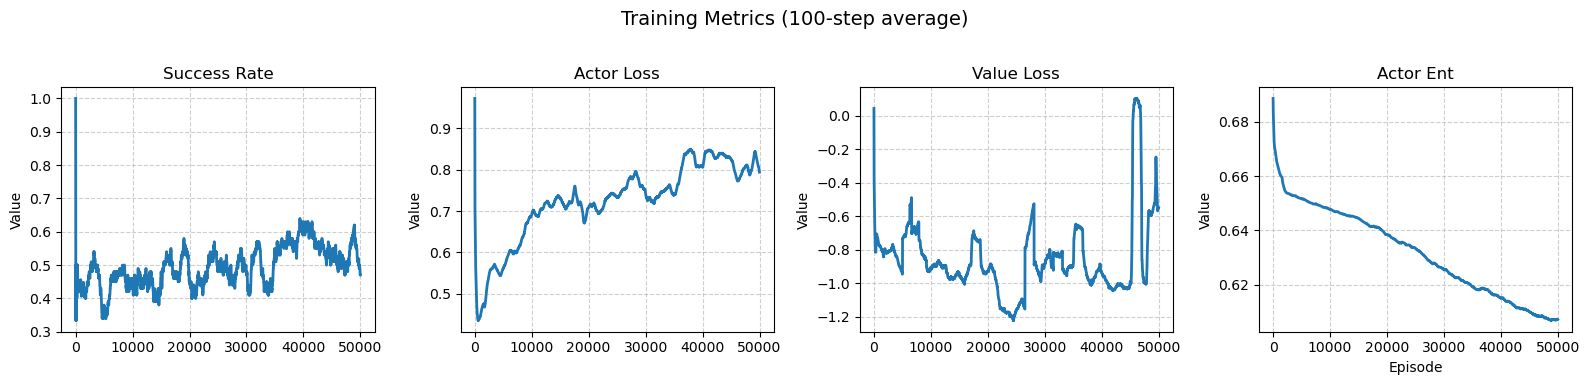

Starting experiment with 12 goals. Runs per goal: 100


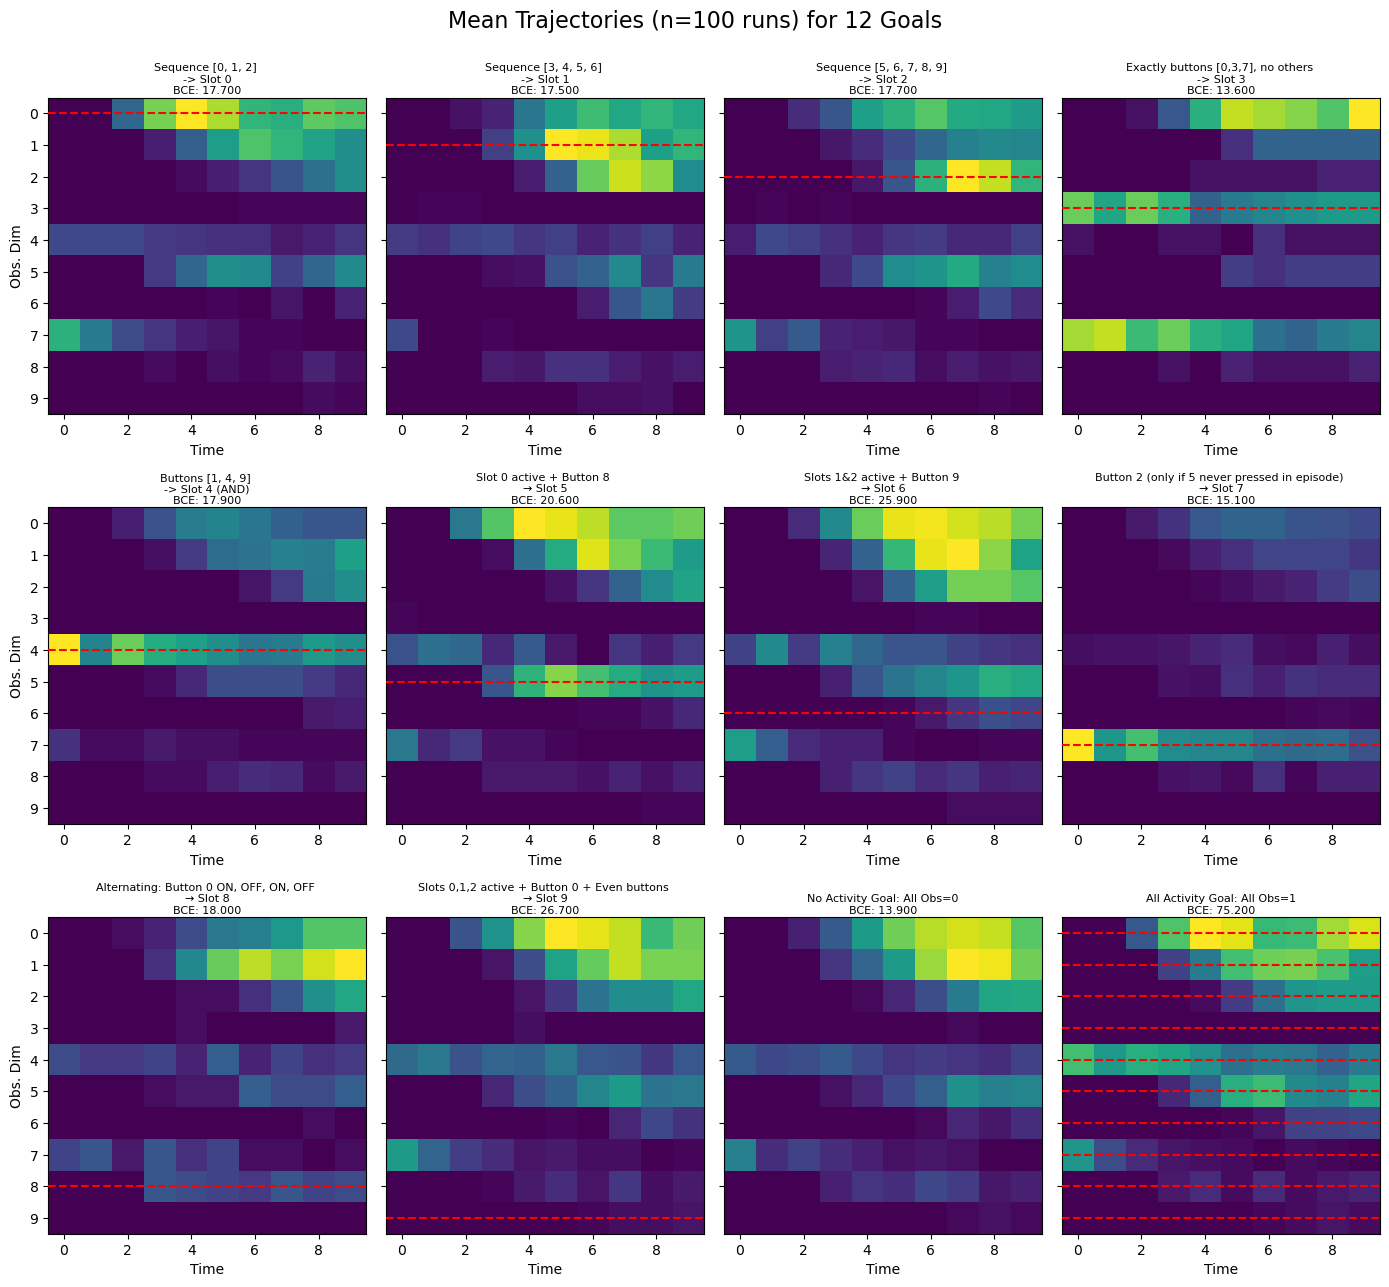

In [35]:
plot_metrics(ac_logger, metrics=["success_rate", "actor_loss","value_loss","actor_ent"])
evaluate_agent_goal_attainment(ac_agent, env, num_runs_per_goal=100, episode_length=episode_length)

## GCSL

In [14]:
num_episodes = 50000
gcsl_logger = ExperimentLogger(log_window_size=100)
gcsl_buffer.clear()
train(agent=gcsl_agent, buffer=gcsl_buffer, goal_sampler=probabilisticGoalSampler, reward_function=reward_function, logger=gcsl_logger, num_episodes=num_episodes, LOG_INTERVAL=100, horizon=gcsl_agent.use_horizon)

Episode 49900, actor_ent: 0.542, kl: 0.317, actor_loss: 0.538, success_rate: 0.260


In [ ]:
plot_metrics(gcsl_logger, metrics=["success_rate", "actor_loss", "actor_ent"])
evaluate_agent_goal_attainment(gcsl_agent, env, num_runs_per_goal=100, episode_length=episode_length)

In [57]:
num_episodes = 50000
gcsl_logger = ExperimentLogger(log_window_size=100)
gcsl_buffer.clear()
train_sequential(agent=gcsl_agent, buffer=gcsl_buffer, goal_sampler=sequentialGoalSampler, reward_function=reward_function, logger=gcsl_logger, num_episodes=num_episodes, LOG_INTERVAL=1000, horizon=gcsl_agent.use_horizon)

Episode 49000, actor_ent: 0.421, kl: 0.303, actor_loss: 0.419, success_rate: 0.050


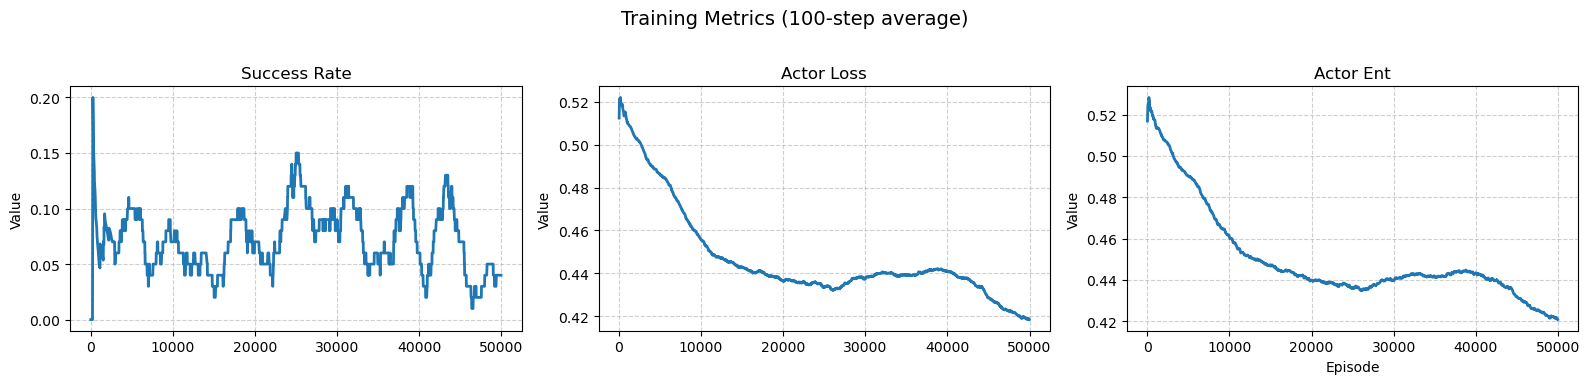

Starting experiment with 12 goals. Runs per goal: 100


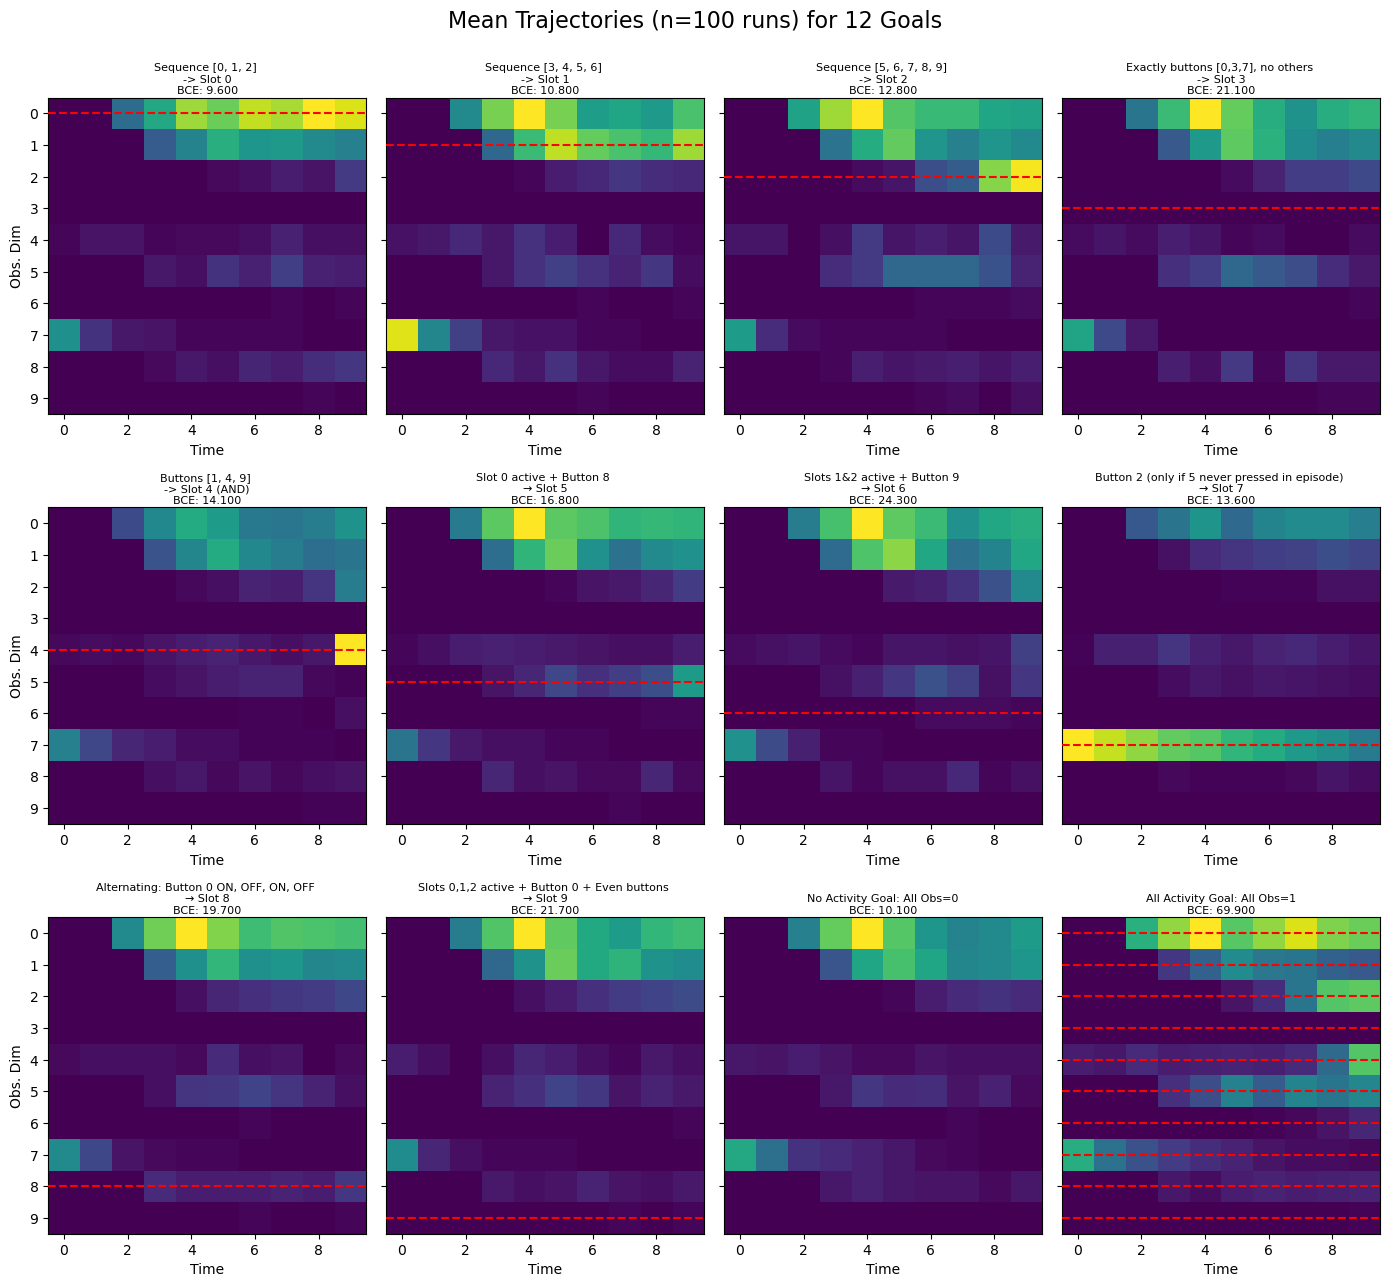

In [58]:
plot_metrics(gcsl_logger, metrics=["success_rate", "actor_loss", "actor_ent"])
evaluate_agent_goal_attainment(gcsl_agent, env, num_runs_per_goal=100, episode_length=episode_length)

## CRL

In [31]:
num_episodes=5000

crl_logger = ExperimentLogger(log_window_size=100)
crl_buffer.clear()

train(agent=crl_agent, buffer=crl_buffer, goal_sampler=prop_impo_goal, reward_function=reward_function, logger=crl_logger, num_episodes=num_episodes, LOG_INTERVAL=100, train_buffer=crl_buffer)

Episode 4900, logits_pos: 0.205, logits_neg: -0.195, q_pos_ratio: 1.225, q_neg_ratio: 0.855, bin_acc: 0.568, cat_acc: 0.001, qf_loss: 0.001, actor_logp: -0.402, actor_ent: 0.401, actor_kl: 0.403, gcbc_loss: 0.977, actor_q_loss: 0.675, success_rate: 0.410


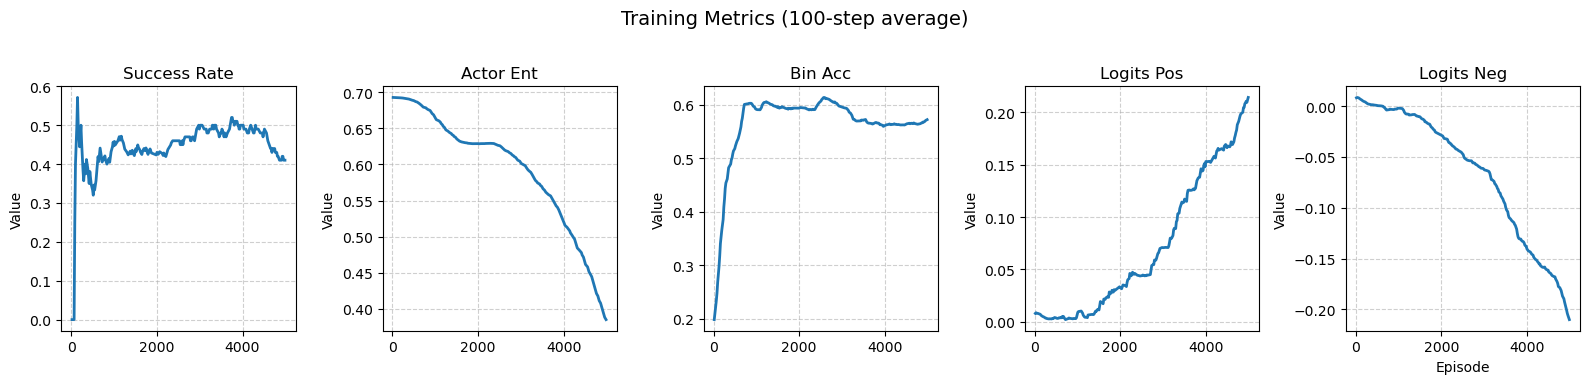

Starting experiment with 12 goals. Runs per goal: 100


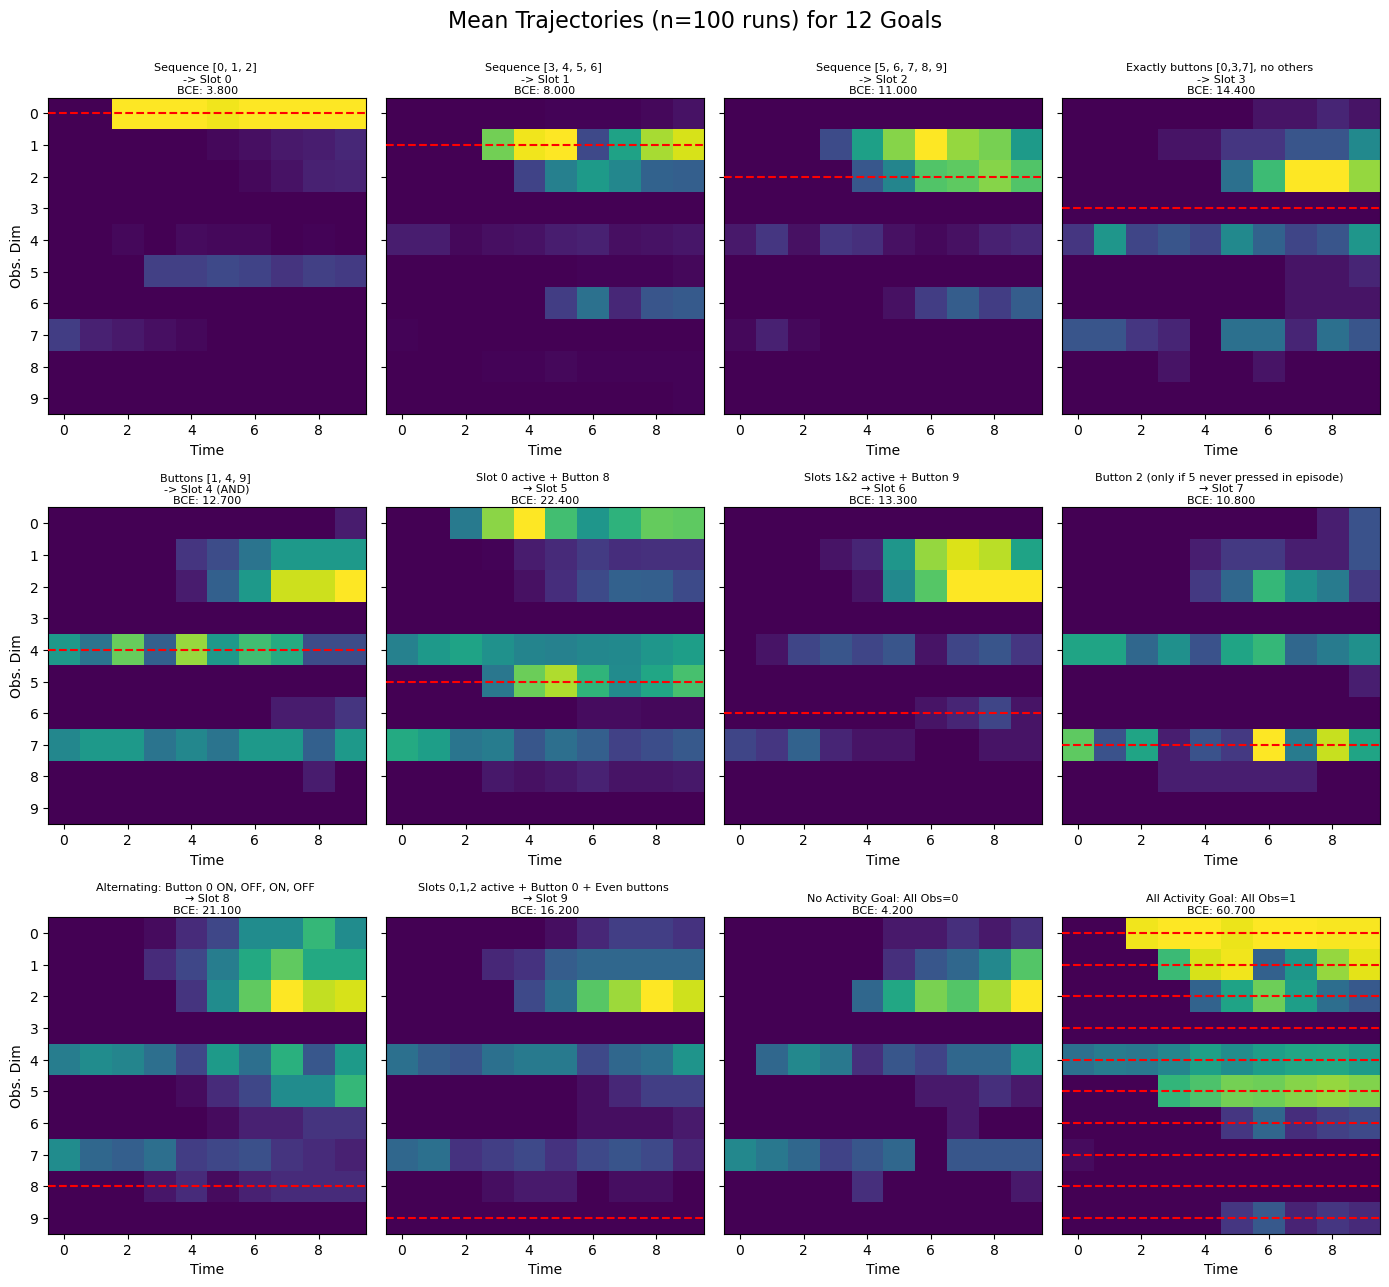

In [32]:
plot_metrics(crl_logger, metrics=["success_rate", "actor_ent", "bin_acc", "logits_pos","logits_neg"])
evaluate_agent_goal_attainment(crl_agent, env, num_runs_per_goal=100, episode_length=episode_length)

## Tasks
1. Think about different & intereseting ways to analyze the agent's performance and behavior. Compare the provided agents based on your ideas.
    - generalization to unseen goals
    - sample efficiency
    - cool visualizations
    - ...

2. Use hindsight experience replay (HER) to train the actor critic agent.
    - compare against agent trained without HER
    - custom buffer with relabeling:
        ```python
        def sample_function(batch_size, trajectory_len, to_device=None, keys=None):
            data = buffer.sample(batch_size, trajectory_len, to_device=to_device, keys=keys)
            if data is None:
                return data
            # hindsight relabeling
            return data
        custom_buffer = FunctionBuffer(sample_function)
        ```

3. Try out different goal sampling strategies. Right now, goals are provided externally with prior knowledge about the environment. Compare performance/behavior/learning of agents trained with different goal sampling strategies.
    - hard to reach goals / impossible goals (what whould that imply for the AC approach relying on distance based rewards?)
    - goals from experience
    - interesting goals (maybe learned)
    - you can use this template to create your own goal sampling method:
        ```python
        class CustomGoalSampler:
            def sample(self, batch_size):
                # return zero goals of shape (batch_size, obs_dim)
                goals = torch.zeros((batch_size, obs_dim), device=device)
                return goal
        ```

4. Analyze how the horizon parameter in GCSL influences learning and policy behavior.
    - deactivate horizon
    - different horizons during evaluation, what happens to the action probabilities
    - ...

Choose **two** of the above tasks and work on them until next time. We will discuss your results in the next excercise session.